In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 1. Upload File
print("Please upload your CSV file:")
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(filename)

Please upload your CSV file:


Saving Amazon_Big_Sales_Dataset_2026.csv to Amazon_Big_Sales_Dataset_2026.csv


In [3]:
# 2. Initial Data Inspection
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    100 non-null    object 
 1   Product_Name  100 non-null    object 
 2   Category      100 non-null    object 
 3   Price_USD     100 non-null    float64
 4   Rating        100 non-null    float64
 5   Review_Count  100 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 4.8+ KB
None

--- First 5 Rows ---
  Product_ID                  Product_Name     Category  Price_USD  Rating  \
0     AZ1001           Power Bank Model-39        Audio     591.53     4.1   
1     AZ1002         External SSD Model-20  Accessories     647.02     3.6   
2     AZ1003          Smart Watch Model-72  Accessories     419.88     4.7   
3     AZ1004        Graphics Card Model-97  Electronics     214.91     4.8   
4     AZ1005  Mechanical Keyboard Model-53    Comput

/tmp/ipykernel_6075/2875877623.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_price, x='Price_USD', y='Category', palette='viridis')


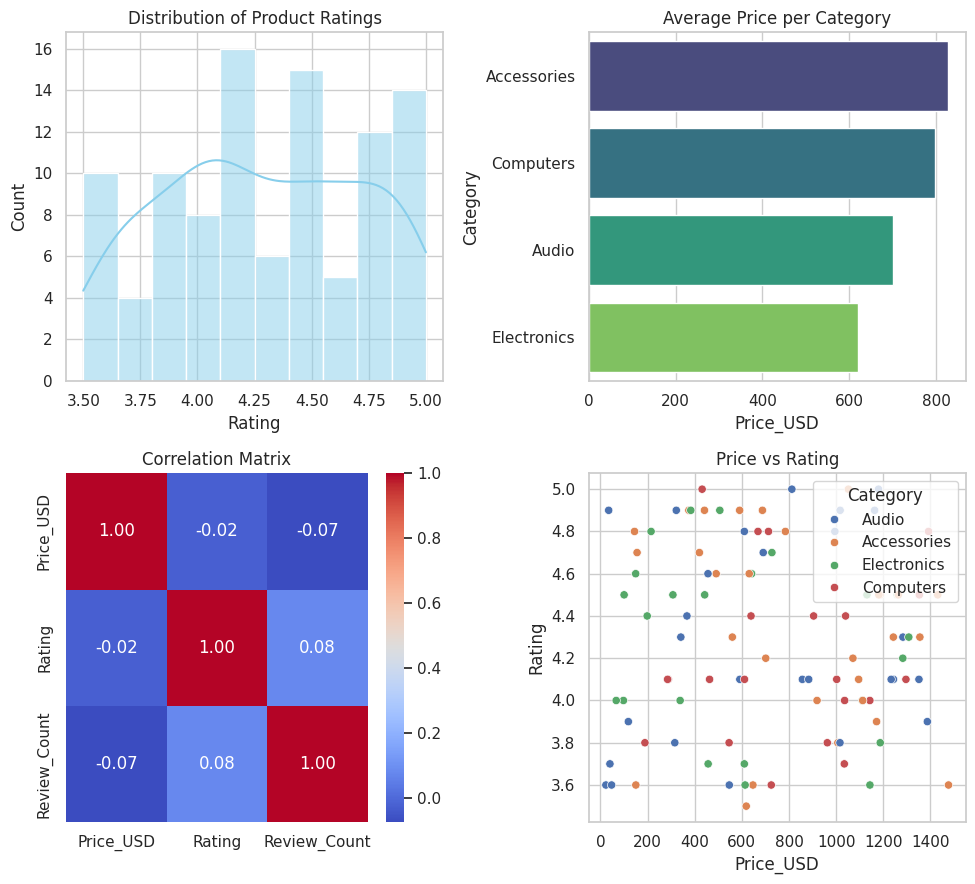

In [15]:
# 3. Data Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 9))

# Plot 1: Rating Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['Rating'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Product Ratings')

# Plot 2: Average Price by Category
plt.subplot(2, 2, 2)
cat_price = df.groupby('Category')['Price_USD'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_price, x='Price_USD', y='Category', palette='viridis')
plt.title('Average Price per Category')

# Plot 3: Correlation Heatmap
plt.subplot(2, 2, 3)
corr = df[['Price_USD', 'Rating', 'Review_Count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

# Plot 4: Price vs Rating
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='Price_USD', y='Rating', hue='Category')
plt.title('Price vs Rating')

plt.tight_layout()
plt.show()

In [5]:
# 4. Data Preprocessing for Machine Learning
# Convert categorical 'Category' to numerical using One-Hot Encoding
df_ml = pd.get_dummies(df, columns=['Category'], drop_first=True)

# Define Features (X) and Target (y)
# We drop Product_ID and Product_Name as they are unique identifiers
X = df_ml.drop(columns=['Product_ID', 'Product_Name', 'Rating'])
y = df_ml['Rating']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# 5. Supervised Learning: Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [7]:

# Predictions
y_pred = model.predict(X_test)

In [8]:
# 6. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")


--- Model Performance ---
Mean Squared Error: 0.1584
R-squared Score: 0.0654


/tmp/ipykernel_6075/3540355683.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='magma')


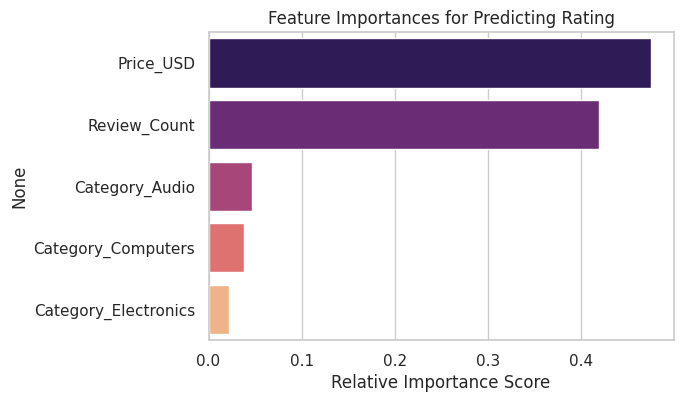

In [10]:
# 7. Feature Importance Analysis
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='magma')
plt.title('Feature Importances for Predicting Rating')
plt.xlabel('Relative Importance Score')
plt.show()